# 07 — XGBoost: Gradient Boosting para Pronóstico de Rentas Cedidas

**Sistema de Análisis y Pronóstico de Rentas Cedidas** | ADRES — Colombia

---

## Arquitectura Analítica

| Fase | Contenido | Método |
|------|-----------|--------|
| **I** | Carga, Feature Engineering avanzado | Lags, calendario, macro, log1p |
| **II** | Exploración de features y correlación | Heatmap, análisis bivariado |
| **III** | Bayesian Optimization de hiperparámetros | Optuna + TimeSeriesSplit |
| **IV** | Modelo final: entrenamiento y validación OOS | Oct–Dic 2025 vs real |
| **V** | Feature Importance + SHAP | Importancia global y contribución local |
| **VI** | Comparativa vs SARIMA / Prophet | MAPE, RMSE, MAE head-to-head |

### Justificación Metodológica

**¿Por qué XGBoost?** Gradient Boosting (Chen & Guestrin, 2016) ensambla
secuencialmente árboles de decisión "débiles", donde cada árbol corrige los
residuos del anterior. Ventajas sobre modelos lineales (SARIMA, Prophet):

1. **Captura no-linealidades:** Los splits de los árboles detectan umbrales
   en el recaudo que los modelos aditivos no pueden representar.
2. **Robustez ante outliers:** Menos sensible a picos de migración ERP
   (Dynamics → Oracle, 2025) que SARIMA.
3. **Feature Importance nativa:** Cuantifica la contribución relativa de
   cada variable macroeconómica (IPC, SMLV, UPC, Consumo_Hogares).
4. **Eficiencia con datos medianos:** Óptimo para ~51 meses de la serie,
   donde redes profundas (LSTM) carecen de masa crítica de datos.

**Serie completa:** Se utilizan datos desde **Oct 2021** (inicio de la serie
disponible) hasta Dic 2025, abarcando 51 meses de observaciones mensuales
del mercado de licores, cigarrillos y juegos de azar.

**Transformación log1p:** Estabiliza la varianza y captura el crecimiento
proporcional de los picos de Ene/Jul (electrocardiograma fiscal).

> **Validación OOS:** Train = Oct 2021 – Sep 2025 (48 meses),
> Test = Oct – Dic 2025 (3 meses con datos **reales**).

In [1]:
# ══════════════════════════════════════════════════════════════
# FASE I — Setup, Carga de Datos y Feature Engineering Avanzado
# ══════════════════════════════════════════════════════════════

%run 00_config.py

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from sklearn.metrics import (mean_absolute_percentage_error,
                             mean_squared_error, mean_absolute_error)
from sklearn.model_selection import TimeSeriesSplit
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# ── Intentar importar Optuna (Bayesian Optimization) ──
try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    OPTUNA_AVAILABLE = True
except ImportError:
    OPTUNA_AVAILABLE = False
    print("  ⚠️ Optuna no disponible — se usará GridSearch manual")

# ── Intentar importar SHAP ──
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print("  ⚠️ SHAP no disponible — solo Importancia de Variables nativa")

# ── Carga de serie mensual procesada ──
csv_path = DATA_PROCESSED / 'serie_mensual.csv'
df_serie = pd.read_csv(csv_path, parse_dates=['Fecha'], index_col='Fecha')
df_serie.index.freq = 'MS'

# ── Carga de datos macroeconómicos ──
csv_macro = DATA_PROCESSED / 'serie_mensual_macro.csv'
df_macro = pd.read_csv(csv_macro, parse_dates=['Fecha'], index_col='Fecha')
df_macro.index.freq = 'MS'

# ══════════════════════════════════════════════════════════════
# SERIE COMPLETA: Oct 2021 – Dic 2025 (51 meses)
# Usa FECHA_INICIO del config centralizado
# ══════════════════════════════════════════════════════════════
serie_xgb = df_serie['Recaudo_Total'].loc[FECHA_INICIO:FECHA_FIN].copy()
macro_xgb = df_macro.loc[FECHA_INICIO:FECHA_FIN].copy()

# ══════════════════════════════════════════════════════════════
# FEATURE ENGINEERING AVANZADO
# ══════════════════════════════════════════════════════════════
df_features = pd.DataFrame(index=serie_xgb.index)

# Variable objetivo (log1p para estabilizar varianza)
df_features['y_raw'] = serie_xgb.values
df_features['y'] = np.log1p(serie_xgb.values)

# ── Variables de Calendario ──
df_features['Mes'] = df_features.index.month
df_features['Trimestre'] = df_features.index.quarter
df_features['Anio'] = df_features.index.year
df_features['Es_Pico_Fiscal'] = df_features['Mes'].isin(MESES_PICO).astype(int)
df_features['Es_Festividad'] = df_features['Mes'].isin(MESES_FESTIVIDAD).astype(int)
df_features['Semestre'] = (df_features['Mes'] > 6).astype(int) + 1

# ── Variables de Tendencia ──
df_features['Trend'] = np.arange(len(df_features))
df_features['Trend_sq'] = df_features['Trend'] ** 2

# ── Variables de Rezago (Lags) ──
# Lag_1: mes anterior (valida hipótesis de "recaudo mes vencido")
# Lag_2: dos meses antes
# Lag_12: mismo mes del año anterior (componente estacional directa)
for lag in [1, 2, 3, 12]:
    df_features[f'Lag_{lag}'] = df_features['y'].shift(lag)

# ── Medias Móviles ──
df_features['MA_3'] = df_features['y'].rolling(3).mean()
df_features['MA_6'] = df_features['y'].rolling(6).mean()
df_features['MA_12'] = df_features['y'].rolling(12).mean()

# ── Variables de Momentum ──
df_features['Diff_1'] = df_features['y'].diff(1)
df_features['Diff_12'] = df_features['y'].diff(12)

# ── Variables Macroeconómicas (obligatorias por protocolo de tesis) ──
MACRO_VARS = ['IPC', 'Salario_Minimo', 'UPC', 'Consumo_Hogares', 'SMLV_COP', 'IPC_Idx']
for var in MACRO_VARS:
    df_features[var] = macro_xgb[var].values

# ── Sin encodings one-hot de Mes (XGBoost maneja la cardinal directamente) ──
# Pero creamos indicadores cíclicos para capturar continuidad
df_features['Mes_sin'] = np.sin(2 * np.pi * df_features['Mes'] / 12)
df_features['Mes_cos'] = np.cos(2 * np.pi * df_features['Mes'] / 12)

# ── Eliminar filas con NaN de lags (primeros 12 meses) ──
df_clean = df_features.dropna().copy()

print(f"{'═'*70}")
print(f"INGENIERÍA DE VARIABLES — XGBoost para Rentas Cedidas")
print(f"{'═'*70}")
print(f"  Serie original:    {len(serie_xgb)} meses ({serie_xgb.index.min().strftime('%b %Y')} – {serie_xgb.index.max().strftime('%b %Y')})")
print(f"  Tras eliminar NaN: {len(df_clean)} meses ({df_clean.index.min().date()} → {df_clean.index.max().date()})")
print(f"  Variables creadas:  {len([c for c in df_clean.columns if c not in ['y', 'y_raw']])}")
print(f"\n  Variables de calendario: Mes, Trimestre, Anio, Es_Pico_Fiscal, Es_Festividad, Semestre")
print(f"  Lags:                    Lag_1, Lag_2, Lag_3, Lag_12")
print(f"  Medias móviles:          MA_3, MA_6, MA_12")
print(f"  Momentum:                Diff_1, Diff_12")
print(f"  Macro:                   {', '.join(MACRO_VARS)}")
print(f"  Cíclicas:                Mes_sin, Mes_cos")
print(f"  Tendencia:               Trend, Trend_sq")

# ══════════════════════════════════════════════════════════════
# SPLIT TRAIN / TEST
# ══════════════════════════════════════════════════════════════
FEATURE_COLS = [c for c in df_clean.columns if c not in ['y', 'y_raw']]

train_mask = df_clean.index <= TRAIN_END
test_mask  = (df_clean.index >= TEST_START) & (df_clean.index <= VALIDATION_END)

X_train = df_clean.loc[train_mask, FEATURE_COLS]
y_train = df_clean.loc[train_mask, 'y']
y_train_raw = df_clean.loc[train_mask, 'y_raw']

X_test = df_clean.loc[test_mask, FEATURE_COLS]
y_test = df_clean.loc[test_mask, 'y']
y_test_raw = df_clean.loc[test_mask, 'y_raw']

print(f"\n{'─'*70}")
print(f"DIVISIÓN ENTRENAMIENTO / PRUEBA")
print(f"{'─'*70}")
print(f"  Entrenamiento: {len(X_train)} meses ({X_train.index.min().date()} → {X_train.index.max().date()}) | {len(FEATURE_COLS)} variables")
print(f"  Prueba:        {len(X_test)} meses ({X_test.index.min().date()} → {X_test.index.max().date()})")
print(f"\n  ✅ Ingeniería de variables completa — {len(FEATURE_COLS)} variables predictoras")

  🎨 Tema profesional aplicado — Tipografía serif, paleta académica, DPI 300
Config cargada -- Datos: BaseRentasVF_limpieza21feb_sin2021_ene_sep.xlsx | Periodo: 2021-10-01 a 2025-12-31
  Tema profesional activo -- DPI 300, tipografia serif, paleta academica


══════════════════════════════════════════════════════════════════════
INGENIERÍA DE VARIABLES — XGBoost para Rentas Cedidas
══════════════════════════════════════════════════════════════════════
  Serie original:    51 meses (Oct 2021 – Dec 2025)
  Tras eliminar NaN: 39 meses (2022-10-01 → 2025-12-01)
  Variables creadas:  25

  Variables de calendario: Mes, Trimestre, Anio, Es_Pico_Fiscal, Es_Festividad, Semestre
  Lags:                    Lag_1, Lag_2, Lag_3, Lag_12
  Medias móviles:          MA_3, MA_6, MA_12
  Momentum:                Diff_1, Diff_12
  Macro:                   IPC, Salario_Minimo, UPC, Consumo_Hogares, SMLV_COP, IPC_Idx
  Cíclicas:                Mes_sin, Mes_cos
  Tendencia:               Trend, Trend_sq

──────────────────────────────────────────────────────────────────────
DIVISIÓN ENTRENAMIENTO / PRUEBA
──────────────────────────────────────────────────────────────────────
  Entrenamiento: 36 meses (2022-10-01 → 2025-09-01) | 25 variables
  Prueba:        3 me

---

## Fase II — Exploración de Features y Análisis de Correlación

Antes del modelado, se examina la estructura de correlación entre las
features ingenieriles y la variable objetivo $y = \log(1 + \text{Recaudo})$.
Esto permite:

1. **Validar los lags:** Confirmar que Lag_1 y Lag_12 son los predictores
   más fuertes (hipótesis de recaudo mes vencido + estacionalidad anual).
2. **Detectar multicolinealidad:** Si IPC e IPC_Idx están altamente
   correlacionados (>0.95), se retiene solo uno para evitar redundancia.
3. **Priorizar features:** Las variables con |r| > 0.3 son candidatas
   fuertes para el modelo.

══════════════════════════════════════════════════════════════════════
CORRELACIÓN DE VARIABLES CON VARIABLE OBJETIVO (log1p Recaudo)
══════════════════════════════════════════════════════════════════════
  Lag_12               r = +0.8690  + ██████████████████████████
  Diff_1               r = +0.7394  + ██████████████████████
  Es_Pico_Fiscal       r = +0.7204  + █████████████████████
  MA_3                 r = +0.5657  + ████████████████
  Diff_12              r = +0.4315  + ████████████
  MA_6                 r = +0.2532  + ███████
  Anio                 r = +0.1961  + █████
  SMLV_COP             r = +0.1924  + █████
  Mes_cos              r = +0.1859  + █████
  MA_12                r = +0.1839  + █████
  Semestre             r = +0.1813  + █████
  Trend_sq             r = +0.1577  + ████
  Trend                r = +0.1523  + ████
  IPC_Idx              r = +0.1443  + ████
  Lag_2                r = +0.0274  + 
  Consumo_Hogares      r = -0.0050  - 
  Lag_1                r = -0.

  📊 Figura guardada: 07_xgboost_correlacion_features.png


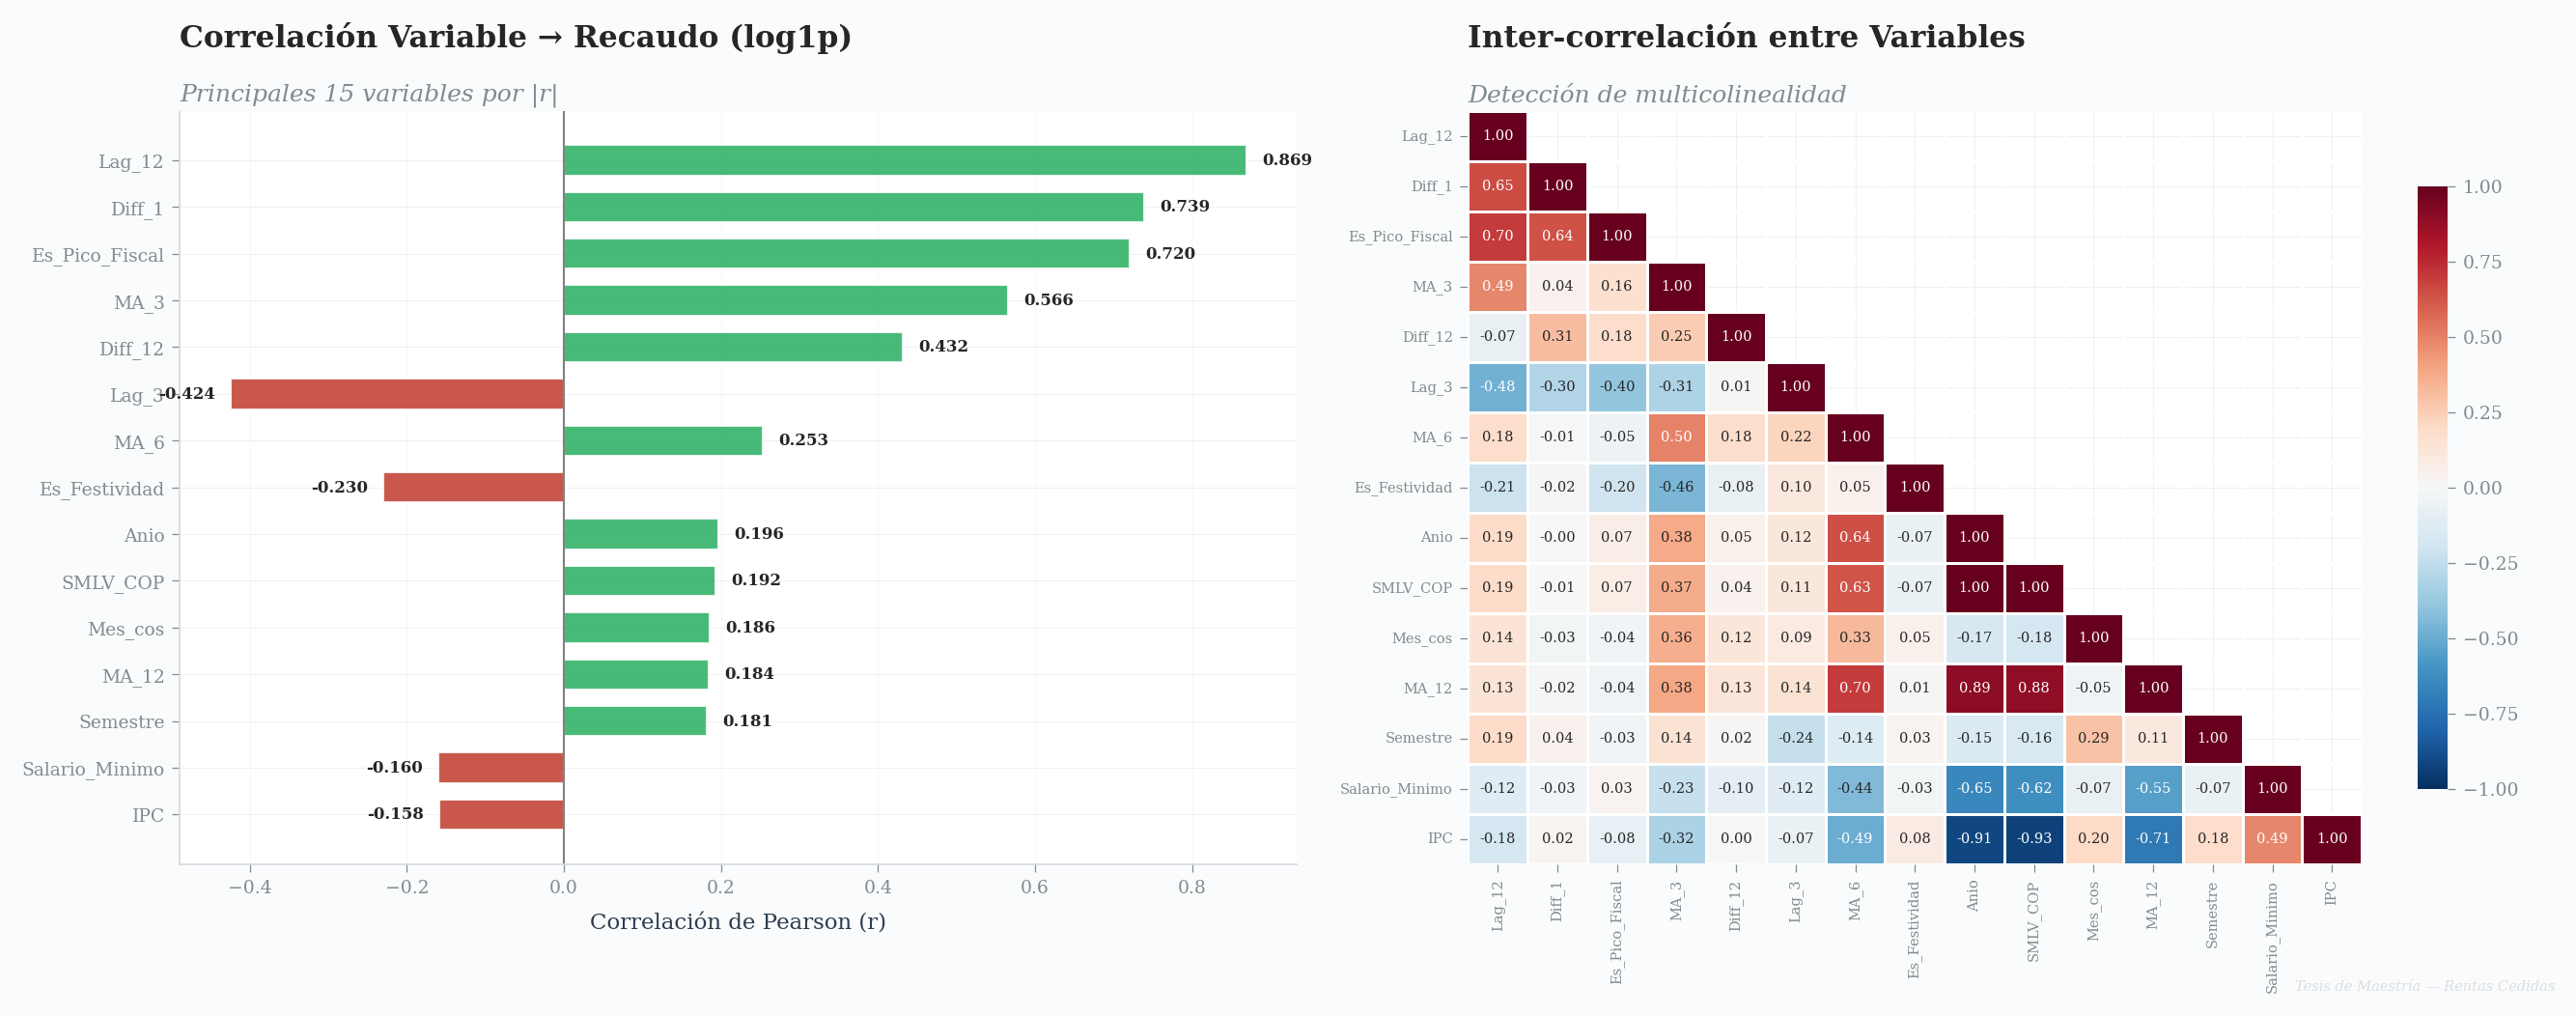


──────────────────────────────────────────────────────────────────────
DIAGNÓSTICO DE MULTICOLINEALIDAD
──────────────────────────────────────────────────────────────────────
  Anio                 ↔ SMLV_COP             r = +0.9982
  Trend                ↔ IPC_Idx              r = +0.9924
  Trend                ↔ Trend_sq             r = +0.9871
  Mes                  ↔ Trimestre            r = +0.9729
  Salario_Minimo       ↔ UPC                  r = +0.9636
  Trend_sq             ↔ IPC_Idx              r = +0.9614
  Anio                 ↔ Trend                r = +0.9513
  Anio                 ↔ IPC_Idx              r = +0.9501
  SMLV_COP             ↔ IPC_Idx              r = +0.9496
  Trend                ↔ SMLV_COP             r = +0.9450
  Trend_sq             ↔ MA_12                r = +0.9443
  Trend                ↔ MA_12                r = +0.9326
  IPC                  ↔ SMLV_COP             r = -0.9325
  Anio                 ↔ Trend_sq             r = +0.9266
  MA_12     

In [2]:
# ══════════════════════════════════════════════════════════════
# FASE II — Exploración de Features y Correlación
# ══════════════════════════════════════════════════════════════

import seaborn as sns

# ── Correlación con variable objetivo ──
corr_target = df_clean[FEATURE_COLS + ['y']].corr()['y'].drop('y').sort_values(ascending=False)

print(f"{'═'*70}")
print(f"CORRELACIÓN DE VARIABLES CON VARIABLE OBJETIVO (log1p Recaudo)")
print(f"{'═'*70}")
for feat, r in corr_target.items():
    bar = '█' * int(abs(r) * 30)
    sign = '+' if r > 0 else '-'
    print(f"  {feat:<20} r = {r:+.4f}  {sign} {bar}")

# ── Heatmap de correlación (features seleccionadas) ──
top_features = corr_target.abs().nlargest(15).index.tolist()
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Panel 1: Correlación con target
ax = axes[0]
colors = [C_QUATERNARY if v > 0 else C_SECONDARY for v in corr_target[top_features].values]
bars = ax.barh(range(len(top_features)), corr_target[top_features].values,
               color=colors, alpha=0.85, edgecolor='white', height=0.65)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features, fontsize=9)
ax.set_xlabel('Correlación de Pearson (r)', fontsize=11)
ax.invert_yaxis()
ax.axvline(0, color='grey', lw=1)
ax.grid(True, alpha=0.3, axis='x')
for bar, val in zip(bars, corr_target[top_features].values):
    offset = 0.02 if val >= 0 else -0.02
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right',
            fontsize=8, fontweight='bold')
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Correlación Variable → Recaudo (log1p)',
                       f'Principales {len(top_features)} variables por |r|')
else:
    ax.set_title('Correlación Variable → Recaudo (log1p)', fontsize=13, fontweight='bold')

# Panel 2: Heatmap de inter-correlación
ax2 = axes[1]
corr_matrix = df_clean[top_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax2, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 7}, linewidths=0.5)
if _VIZ_THEME_LOADED:
    titulo_profesional(ax2, 'Inter-correlación entre Variables',
                       'Detección de multicolinealidad')
else:
    ax2.set_title('Inter-correlación entre Variables', fontsize=13, fontweight='bold')
ax2.tick_params(axis='both', labelsize=7)

plt.tight_layout()
if _VIZ_THEME_LOADED:
    marca_agua(fig)
    guardar_figura(fig, '07_xgboost_correlacion_features', OUTPUTS_FIGURES)
plt.show()

# ── Diagnóstico de multicolinealidad ──
print(f"\n{'─'*70}")
print(f"DIAGNÓSTICO DE MULTICOLINEALIDAD")
print(f"{'─'*70}")
high_corr_pairs = []
cols = FEATURE_COLS
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        r = df_clean[cols[i]].corr(df_clean[cols[j]])
        if abs(r) > 0.90:
            high_corr_pairs.append((cols[i], cols[j], r))
if high_corr_pairs:
    for a, b, r in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
        print(f"  {a:<20} ↔ {b:<20} r = {r:+.4f}")
    print(f"\n  → XGBoost es robusto ante multicolinealidad (no afecta predicción)")
    print(f"    Sin embargo, la Importancia de Variables puede diluirse entre variables correlacionadas")
else:
    print(f"  No se detectaron pares con |r| > 0.90")

---

## Fase III — Optimización Bayesiana de Hiperparámetros

Se utiliza **Optuna** (Akiba et al., 2019) con validación cruzada temporal
(`TimeSeriesSplit`) para encontrar la configuración óptima de XGBoost.

### Espacio de Búsqueda

| Hiperparámetro | Rango | Justificación |
|----------------|-------|---------------|
| `n_estimators` | 50–500 | Número de árboles secuenciales |
| `max_depth` | 3–8 | Profundidad máxima (3–5 conservador, 6–8 agresivo) |
| `learning_rate` | 0.01–0.3 | Tasa de aprendizaje (shrinkage) |
| `subsample` | 0.6–1.0 | Fracción de muestras por árbol |
| `colsample_bytree` | 0.5–1.0 | Fracción de features por árbol |
| `min_child_weight` | 1–10 | Regularización: mínimo peso en hoja |
| `gamma` | 0–5 | Regularización: ganancia mínima para split |
| `reg_alpha` (L1) | 0–5 | Lasso regularization |
| `reg_lambda` (L2) | 0–5 | Ridge regularization |

### Validación Cruzada Temporal

Se usa `TimeSeriesSplit(n_splits=3)` para respetar la estructura temporal
y evitar data leakage. La métrica de optimización es **RMSE** sobre los
folds de validación.

> **Nota:** Optuna usa Tree-Structured Parzen Estimator (TPE) como
> sampler, más eficiente que GridSearch exhaustivo para espacios
> de alta dimensionalidad.

══════════════════════════════════════════════════════════════════════
OPTIMIZACIÓN BAYESIANA — Optuna (TPE Sampler)
══════════════════════════════════════════════════════════════════════
  Espacio: 9 hiperparámetros | CV: TimeSeriesSplit(3 folds)
  Trials: 200 (Tree-Structured Parzen Estimator)




──────────────────────────────────────────────────────────────────────
MEJOR CONFIGURACIÓN ENCONTRADA (Iteración #133)
──────────────────────────────────────────────────────────────────────
  n_estimators             : 152
  max_depth                : 5
  learning_rate            : 0.27828005449197507
  subsample                : 0.7569790468153137
  colsample_bytree         : 0.6052844886863629
  min_child_weight         : 3
  gamma                    : 0.0040299762609678335
  reg_alpha                : 0.44871974173647844
  reg_lambda               : 1.025395002311958
  CV RMSE (log1p):        0.147441


  📊 Figura guardada: 07_xgboost_optuna_convergencia.png


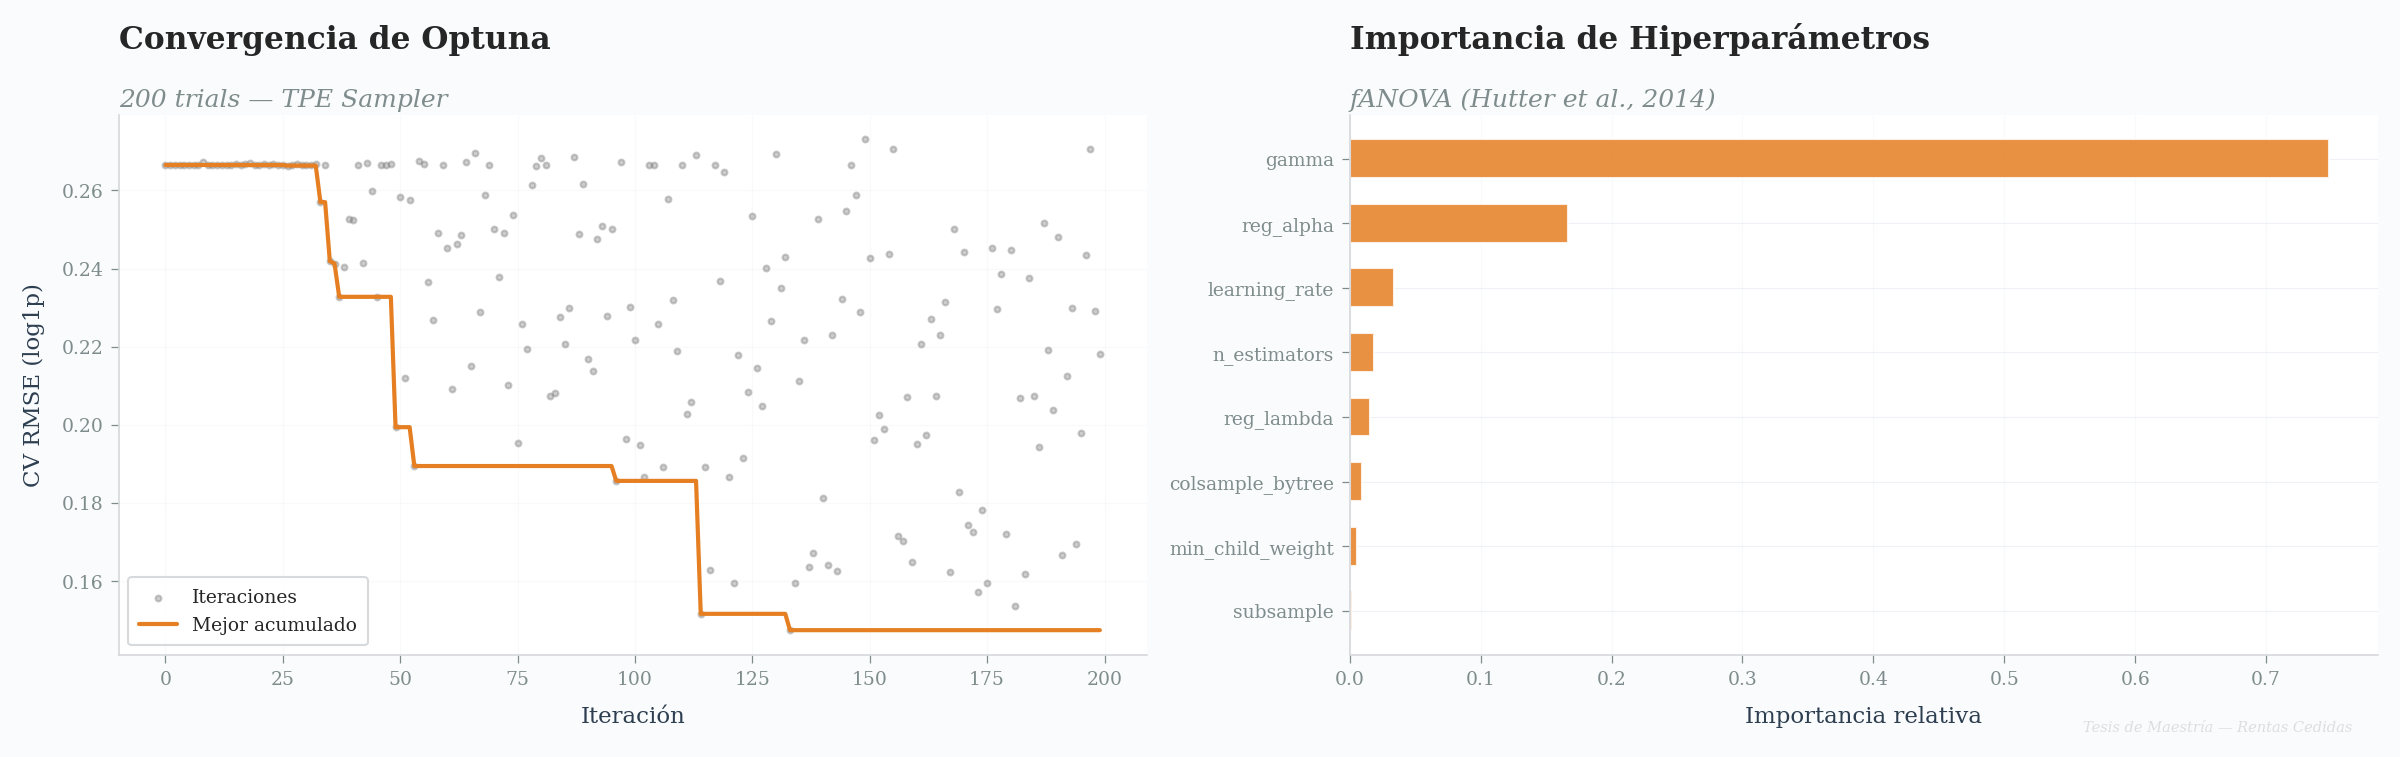


  ✅ Hiperparámetros óptimos seleccionados


In [3]:
# ══════════════════════════════════════════════════════════════
# FASE III — Optimización Bayesiana de Hiperparámetros (Optuna)
# ══════════════════════════════════════════════════════════════

# ── Validación cruzada temporal ──
tscv = TimeSeriesSplit(n_splits=3)

if OPTUNA_AVAILABLE:
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 500),
            'max_depth': trial.suggest_int('max_depth', 3, 8),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'gamma': trial.suggest_float('gamma', 0, 5.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 0, 5.0),
            'reg_lambda': trial.suggest_float('reg_lambda', 0, 5.0),
            'random_state': 42,
            'verbosity': 0,
        }
        
        rmses = []
        for train_idx, val_idx in tscv.split(X_train):
            X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
            
            model = xgb.XGBRegressor(**params)
            model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
            
            y_pred = model.predict(X_val)
            rmse = np.sqrt(mean_squared_error(y_val, y_pred))
            rmses.append(rmse)
        
        return np.mean(rmses)
    
    print(f"{'═'*70}")
    print(f"OPTIMIZACIÓN BAYESIANA — Optuna (TPE Sampler)")
    print(f"{'═'*70}")
    print(f"  Espacio: 9 hiperparámetros | CV: TimeSeriesSplit(3 folds)")
    print(f"  Trials: 200 (Tree-Structured Parzen Estimator)")
    print()
    
    study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=200, show_progress_bar=False)
    
    best_params = study.best_params
    best_params['random_state'] = 42
    best_params['verbosity'] = 0
    
    print(f"\n{'─'*70}")
    print(f"MEJOR CONFIGURACIÓN ENCONTRADA (Iteración #{study.best_trial.number})")
    print(f"{'─'*70}")
    for k, v in best_params.items():
        if k not in ['random_state', 'verbosity']:
            print(f"  {k:<25}: {v}")
    print(f"  CV RMSE (log1p):        {study.best_value:.6f}")

else:
    # Fallback: GridSearch manual con parámetros razonables
    print(f"{'═'*70}")
    print(f"BÚSQUEDA DE HIPERPARÁMETROS — GridSearch Manual")
    print(f"{'═'*70}")
    
    param_grid = [
        {'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8},
        {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8},
        {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.9, 'colsample_bytree': 0.9},
        {'n_estimators': 150, 'max_depth': 6, 'learning_rate': 0.08, 'subsample': 0.7, 'colsample_bytree': 0.7},
        {'n_estimators': 250, 'max_depth': 4, 'learning_rate': 0.03, 'subsample': 0.85, 'colsample_bytree': 0.85},
    ]
    
    best_rmse = np.inf
    best_params = None
    for i, params in enumerate(param_grid):
        params.update({'min_child_weight': 3, 'gamma': 0.1, 'reg_alpha': 0.1, 'reg_lambda': 1.0,
                       'random_state': 42, 'verbosity': 0})
        rmses = []
        for train_idx, val_idx in tscv.split(X_train):
            X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
            model = xgb.XGBRegressor(**params)
            model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
            rmse = np.sqrt(mean_squared_error(y_val, model.predict(X_val)))
            rmses.append(rmse)
        avg_rmse = np.mean(rmses)
        print(f"  Config {i+1}: n={params['n_estimators']}, depth={params['max_depth']}, "
              f"lr={params['learning_rate']} → RMSE={avg_rmse:.6f}")
        if avg_rmse < best_rmse:
            best_rmse = avg_rmse
            best_params = params.copy()
    
    print(f"\n  Mejor: RMSE = {best_rmse:.6f}")

# ── Visualización de convergencia (si Optuna) ──
if OPTUNA_AVAILABLE:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Panel 1: Historial de optimización
    ax = axes[0]
    trials = [t.value for t in study.trials]
    best_so_far = [min(trials[:i+1]) for i in range(len(trials))]
    ax.scatter(range(len(trials)), trials, s=8, alpha=0.4, color='grey', label='Iteraciones')
    ax.plot(best_so_far, color=C_QUINARY, lw=2, label='Mejor acumulado')
    ax.set_xlabel('Iteración', fontsize=11)
    ax.set_ylabel('CV RMSE (log1p)', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    if _VIZ_THEME_LOADED:
        titulo_profesional(ax, 'Convergencia de Optuna',
                           f'{len(trials)} trials — TPE Sampler')
    else:
        ax.set_title('Convergencia de Optuna', fontsize=13, fontweight='bold')
    
    # Panel 2: Importancia de hiperparámetros
    ax2 = axes[1]
    try:
        param_importances = optuna.importance.get_param_importances(study)
        names = list(param_importances.keys())[:8]
        values = [param_importances[n] for n in names]
        ax2.barh(range(len(names)), values, color=C_QUINARY, alpha=0.85,
                 edgecolor='white', height=0.6)
        ax2.set_yticks(range(len(names)))
        ax2.set_yticklabels(names, fontsize=9)
        ax2.invert_yaxis()
        ax2.set_xlabel('Importancia relativa', fontsize=11)
        ax2.grid(True, alpha=0.3, axis='x')
        if _VIZ_THEME_LOADED:
            titulo_profesional(ax2, 'Importancia de Hiperparámetros',
                               'fANOVA (Hutter et al., 2014)')
        else:
            ax2.set_title('Importancia de Hiperparámetros', fontsize=13, fontweight='bold')
    except Exception:
        ax2.text(0.5, 0.5, 'Importancia de HP\nno disponible', ha='center',
                 va='center', fontsize=14, transform=ax2.transAxes)
    
    plt.tight_layout()
    if _VIZ_THEME_LOADED:
        marca_agua(fig)
        guardar_figura(fig, '07_xgboost_optuna_convergencia', OUTPUTS_FIGURES)
    plt.show()

print(f"\n  ✅ Hiperparámetros óptimos seleccionados")

---

## Fase IV — Modelo Final: Entrenamiento y Validación OOS

Se entrena el modelo XGBoost con los hiperparámetros óptimos sobre el
set de train completo (Oct 2021 – Sep 2025) y se evalúa contra los datos
**reales** de Oct–Dic 2025.

### Protocolo de Validación

1. **Entrenamiento:** XGBRegressor con `best_params` sobre `X_train` / `y_train`
2. **Predicción OOS:** Sobre `X_test` (Oct–Dic 2025)
3. **Retransformación:** `expm1(ŷ)` para convertir de log1p a pesos colombianos
4. **Métricas:** MAPE, RMSE, MAE contra valores reales observados

══════════════════════════════════════════════════════════════════════
VALIDACIÓN OUT-OF-SAMPLE — XGBoost
══════════════════════════════════════════════════════════════════════
  Periodo test:  2025-10 → 2025-12 (3 meses)

──────────────────────────────────────────────────────────────────────
Mes                     Real      Pronóstico        Error   Error%
──────────────────────────────────────────────────────────────────────
  2025-10    $        313.0MM  $        294.6MM  $     -18.4MM    -5.9%
  2025-11    $        273.8MM  $        269.7MM  $      -4.1MM    -1.5%
  2025-12    $        241.0MM  $        222.2MM  $     -18.8MM    -7.8%
──────────────────────────────────────────────────────────────────────
  MAPE:  5.05%
  RMSE:  $15.4 MM COP
  MAE:   $13.8 MM COP


  📊 Figura guardada: 07_xgboost_oos_validacion.png


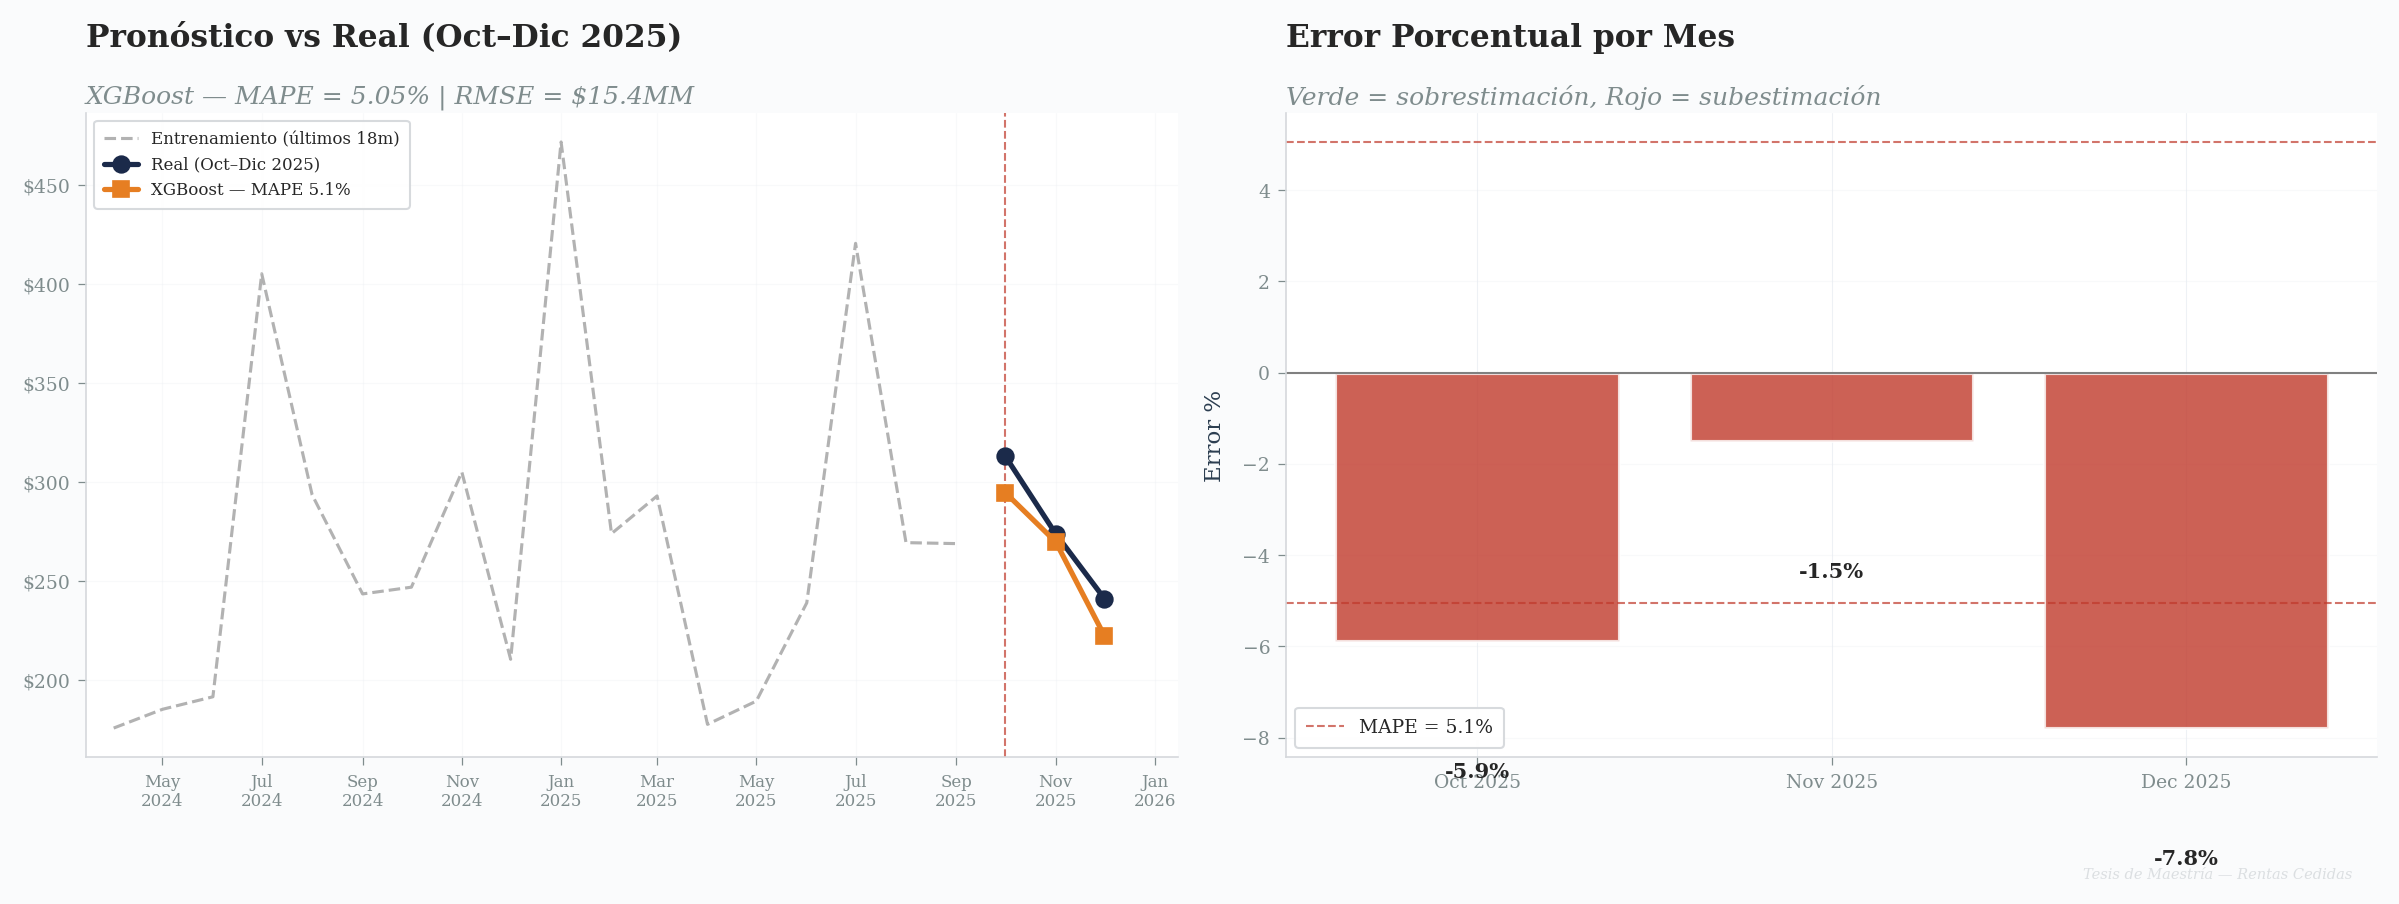


  ✅ Pronóstico OOS guardado: xgboost_forecast.csv


In [4]:
# ══════════════════════════════════════════════════════════════
# FASE IV — Modelo Final: Entrenamiento y Validación OOS
# ══════════════════════════════════════════════════════════════

# ── Entrenar modelo final con hiperparámetros óptimos ──
model_final = xgb.XGBRegressor(**best_params)
model_final.fit(X_train, y_train,
                eval_set=[(X_train, y_train), (X_test, y_test)],
                verbose=False)

# ── Predicción en escala log1p ──
y_pred_log = model_final.predict(X_test)

# ── Retransformar a escala real (pesos COP) ──
y_pred_real = np.expm1(y_pred_log)
y_real = y_test_raw.values

# ── Métricas OOS ──
mape = mean_absolute_percentage_error(y_real, y_pred_real) * 100
rmse = np.sqrt(mean_squared_error(y_real, y_pred_real))
mae  = mean_absolute_error(y_real, y_pred_real)

print(f"{'═'*70}")
print(f"VALIDACIÓN OUT-OF-SAMPLE — XGBoost")
print(f"{'═'*70}")
print(f"  Periodo test:  {X_test.index.min().strftime('%Y-%m')} → {X_test.index.max().strftime('%Y-%m')} ({len(X_test)} meses)")
print(f"\n{'─'*70}")
print(f"{'Mes':<12} {'Real':>15} {'Pronóstico':>15} {'Error':>12} {'Error%':>8}")
print(f"{'─'*70}")

for j, fecha in enumerate(X_test.index):
    real = y_real[j]
    pred = y_pred_real[j]
    err = pred - real
    err_pct = (pred - real) / real * 100
    print(f"  {fecha.strftime('%Y-%m'):<10} ${real/1e9:>13,.1f}MM  ${pred/1e9:>13,.1f}MM  "
          f"${err/1e9:>10,.1f}MM  {err_pct:>6.1f}%")

print(f"{'─'*70}")
print(f"  MAPE:  {mape:.2f}%")
print(f"  RMSE:  ${rmse/1e9:.1f} MM COP")
print(f"  MAE:   ${mae/1e9:.1f} MM COP")

# ── Visualización: Real vs Pronóstico ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: Contexto histórico + OOS
ax = axes[0]
n_hist = min(18, len(y_train))
train_dates = X_train.index[-n_hist:]
train_vals = y_train_raw.values[-n_hist:]
ax.plot(train_dates, train_vals/1e9, color='grey', lw=1.5, ls='--',
        alpha=0.6, label='Entrenamiento (últimos 18m)')
ax.plot(X_test.index, y_real/1e9, color=C_PRIMARY, lw=2.5,
        marker='o', markersize=8, label='Real (Oct–Dic 2025)', zorder=5)
ax.plot(X_test.index, y_pred_real/1e9, color=C_QUINARY, lw=2.5,
        marker='s', markersize=8, label=f'XGBoost — MAPE {mape:.1f}%', zorder=5)
ax.axvline(pd.Timestamp(TEST_START), color=C_SECONDARY, ls='--', lw=1, alpha=0.7)
ax.set_xlim(pd.Timestamp('2024-03-15'), pd.Timestamp('2026-01-15'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax.tick_params(axis='x', labelsize=8)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8, loc='upper left')
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Pronóstico vs Real (Oct–Dic 2025)',
                       f'XGBoost — MAPE = {mape:.2f}% | RMSE = ${rmse/1e9:.1f}MM')
    formato_pesos_eje(ax, eje='y')
else:
    ax.set_title(f'XGBoost — Validación OOS (MAPE={mape:.2f}%)',
                 fontsize=12, fontweight='bold')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(formato_pesos))

# Panel 2: Barras de error porcentual
ax2 = axes[1]
meses_label = [f.strftime('%b %Y') for f in X_test.index]
errores_pct = [(y_pred_real[k] - y_real[k]) / y_real[k] * 100
               for k in range(len(y_real))]
clr_pos, clr_neg = '#27AE60', '#C0392B'
colors_bar = [clr_pos if e >= 0 else clr_neg for e in errores_pct]
ax2.bar(meses_label, errores_pct, color=colors_bar, alpha=0.8,
        edgecolor='white', lw=1.5)
ax2.axhline(0, color='grey', lw=1)
ax2.axhline(mape, color=C_SECONDARY, ls='--', lw=1, alpha=0.7,
            label=f'MAPE = {mape:.1f}%')
ax2.axhline(-mape, color=C_SECONDARY, ls='--', lw=1, alpha=0.7)
for k, (m, e) in enumerate(zip(meses_label, errores_pct)):
    offset = 1.5 if e >= 0 else -3
    ax2.text(k, e + offset, f'{e:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax2.set_ylabel('Error %', fontsize=11)
ax2.grid(True, alpha=0.3, axis='y')
ax2.legend(fontsize=9)
if _VIZ_THEME_LOADED:
    titulo_profesional(ax2, 'Error Porcentual por Mes',
                       'Verde = sobrestimación, Rojo = subestimación')
else:
    ax2.set_title('Error % por Mes', fontsize=12, fontweight='bold')

plt.tight_layout()
if _VIZ_THEME_LOADED:
    marca_agua(fig)
    guardar_figura(fig, '07_xgboost_oos_validacion', OUTPUTS_FIGURES)
plt.show()

# ── Guardar pronóstico OOS ──
df_oos = pd.DataFrame({
    'Fecha': X_test.index,
    'Real': y_real,
    'Pronostico_XGBoost': y_pred_real,
    'Error_Abs': np.abs(y_pred_real - y_real),
    'Error_Pct': (y_pred_real - y_real) / y_real * 100
})
df_oos.to_csv(OUTPUTS_FORECASTS / 'xgboost_forecast.csv', index=False)
print(f"\n  ✅ Pronóstico OOS guardado: xgboost_forecast.csv")

---

## Fase V — Feature Importance y Análisis SHAP

### Interpretabilidad del Modelo

XGBoost ofrece dos niveles de interpretación:

1. **Feature Importance (Gain):** Cuánta reducción de error aporta cada
   variable al ser seleccionada para un split. Las variables con mayor
   Gain tienen mayor peso predictivo global.

2. **SHAP Values (Lundberg & Lee, 2017):** Descomposición aditiva del
   aporte marginal de cada feature a cada predicción individual.
   Permite responder: *"¿Por qué el modelo predijo \$313MM para Oct 2025?"*

> **Relevancia para tesis:** La Feature Importance valida empíricamente
> la hipótesis del tutor: el IPC "va porque va" como variable prioriatria.

══════════════════════════════════════════════════════════════════════
IMPORTANCIA DE VARIABLES (Ganancia) — XGBoost
══════════════════════════════════════════════════════════════════════
  MA_3                  29.65%  █████████████████████████████
  Lag_12                27.20%  ███████████████████████████
  Diff_1                14.17%  ██████████████
  Es_Pico_Fiscal         7.74%  ███████
  Trend                  6.57%  ██████
  Mes_sin                5.51%  █████
  MA_12                  4.12%  ████
  Diff_12                3.33%  ███
  Lag_2                  0.85%  
  Lag_1                  0.85%  

──────────────────────────────────────────────────────────────────────
DISTRIBUCIÓN POR TIPO DE VARIABLE
──────────────────────────────────────────────────────────────────────
  Macroeconómicas:      0.0% 
  Lags / Momentum:     80.2% MA_3, Lag_12, Diff_1, MA_12, Diff_12, Lag_2, Lag_1
  Calendario:          13.3% Es_Pico_Fiscal, Mes_sin
  Tendencia:            6.6%


  📊 Figura guardada: 07_xgboost_feature_importance.png


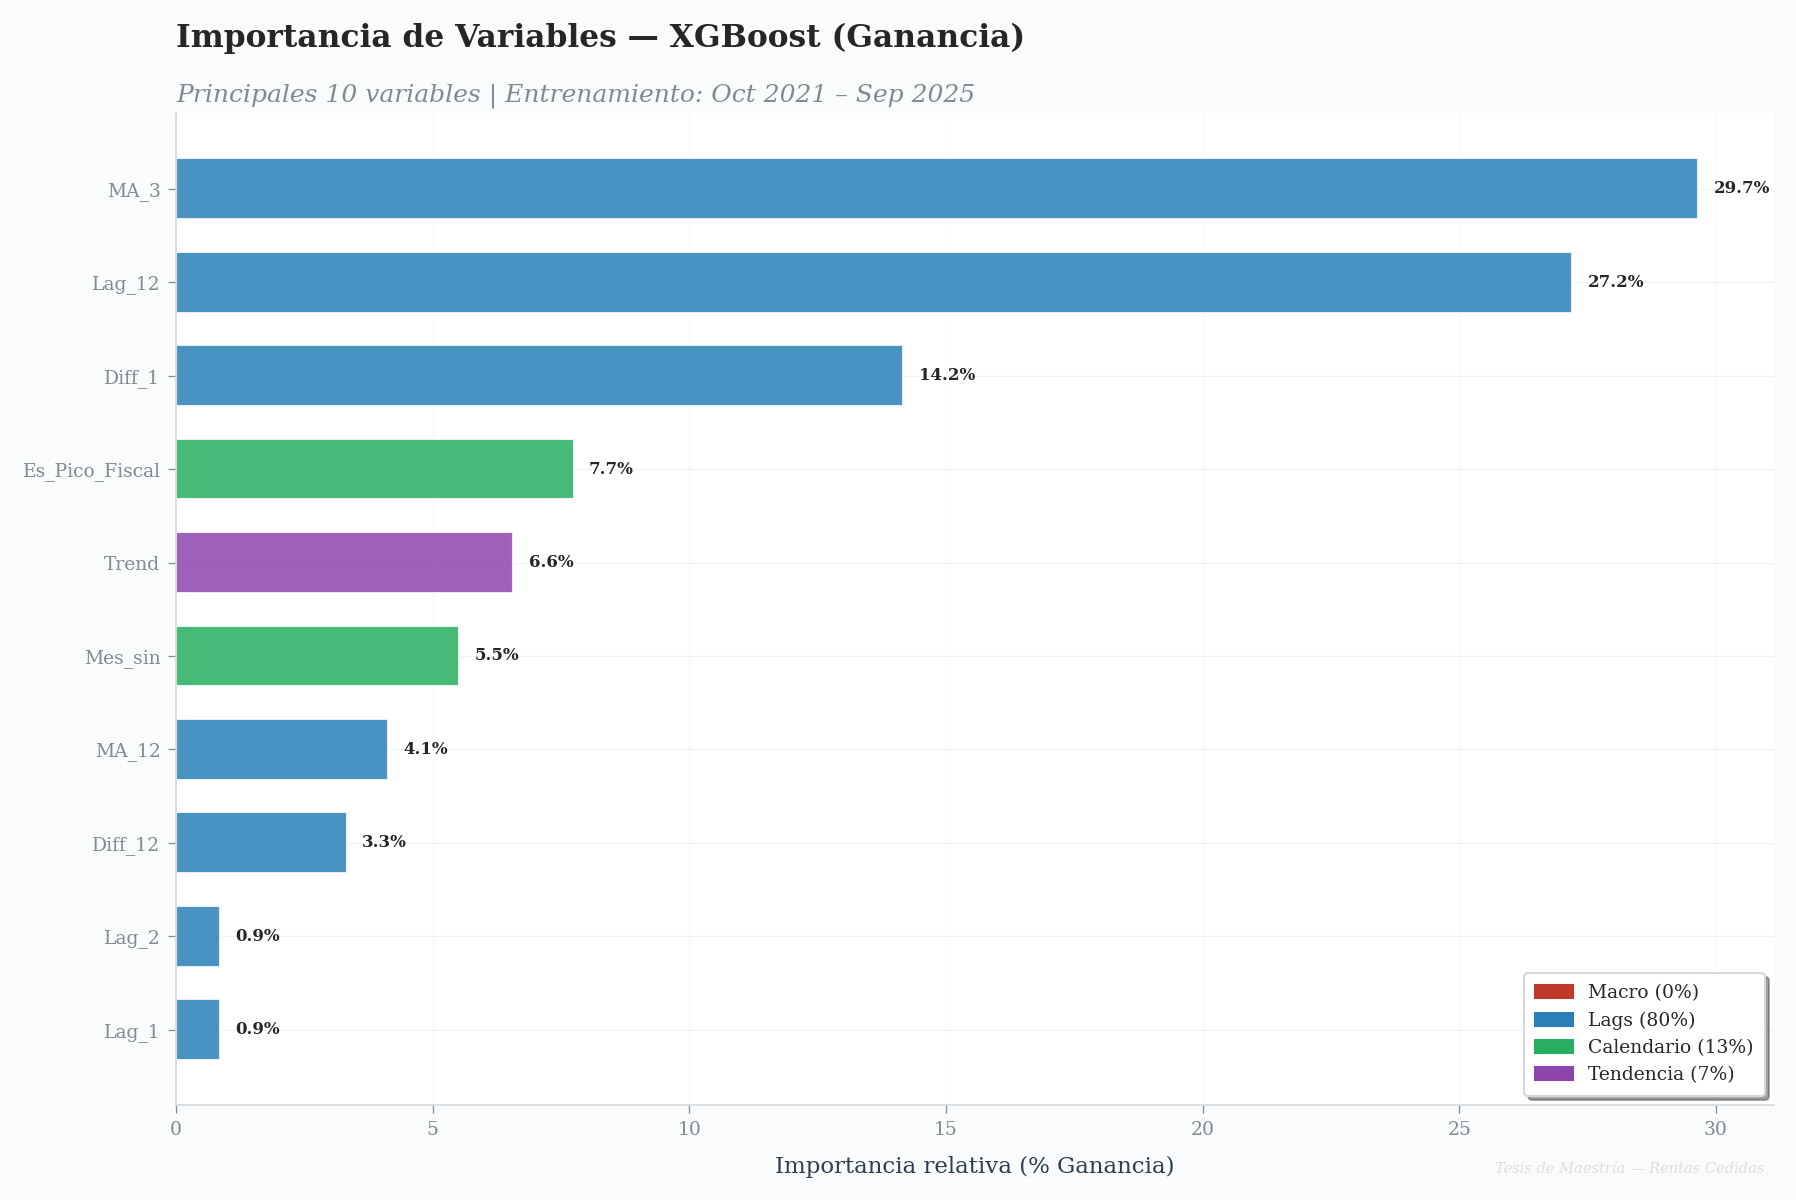


══════════════════════════════════════════════════════════════════════
VALORES SHAP — Contribución Local de Cada Variable
══════════════════════════════════════════════════════════════════════


  📊 Figura guardada: 07_xgboost_shap.png


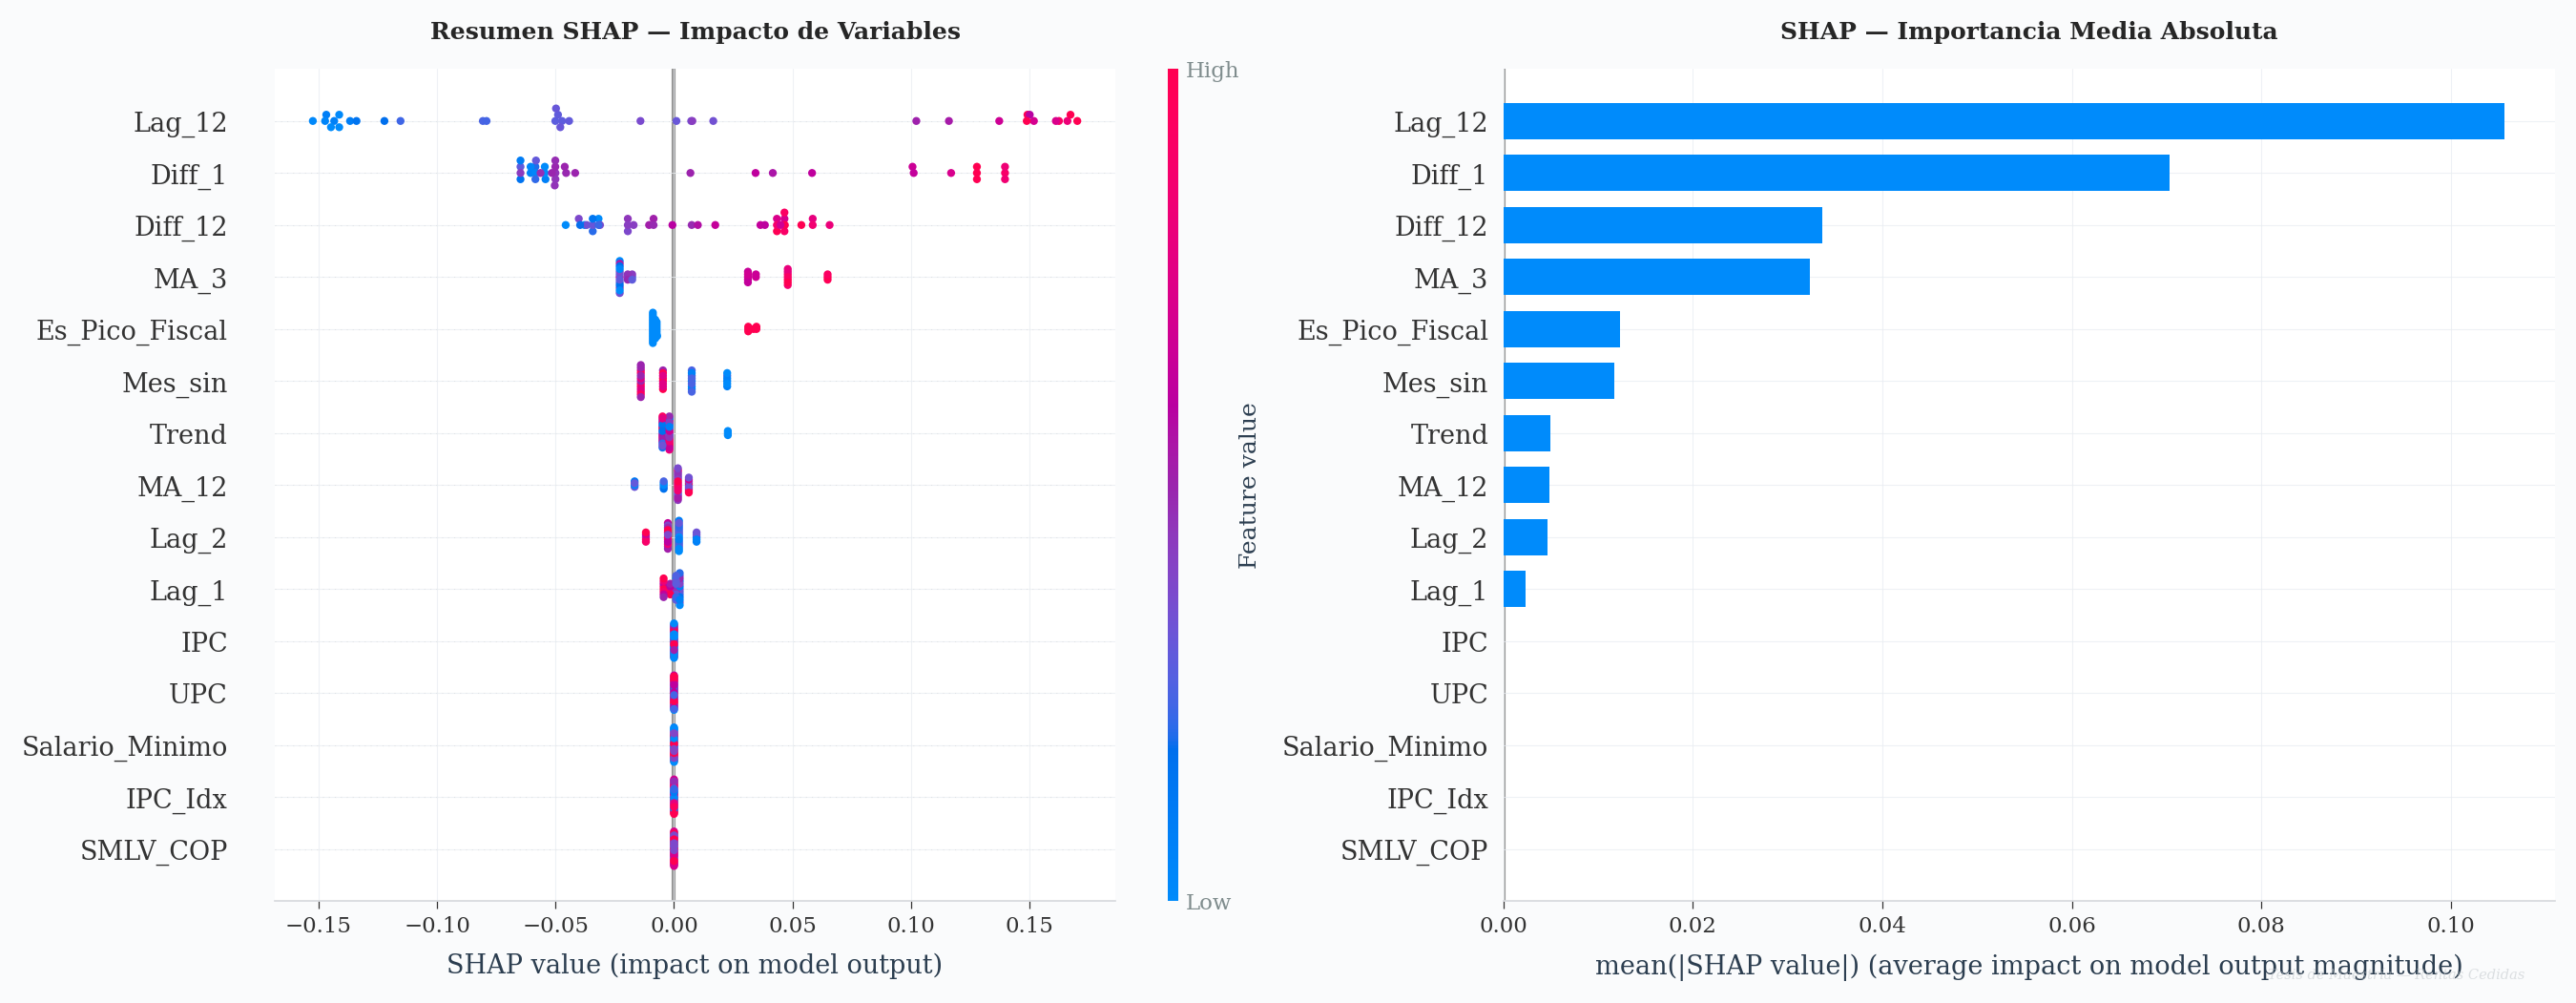


  Contribuciones SHAP para cada mes OOS:

  2025-10 (Pred: $294.6MM)
    Diff_1               SHAP = +0.0583
    Diff_12              SHAP = +0.0537
    MA_3                 SHAP = +0.0312
    Mes_sin              SHAP = +0.0075
    Es_Pico_Fiscal       SHAP = -0.0073

  2025-11 (Pred: $269.7MM)
    Lag_12               SHAP = +0.1372
    Diff_1               SHAP = -0.0648
    MA_3                 SHAP = +0.0480
    Diff_12              SHAP = -0.0396
    Lag_2                SHAP = -0.0119

  2025-12 (Pred: $222.2MM)
    Lag_12               SHAP = -0.1174
    Diff_1               SHAP = -0.0583
    Diff_12              SHAP = +0.0466
    MA_3                 SHAP = +0.0312
    Mes_sin              SHAP = -0.0140

  ✅ Análisis de importancia completado


In [5]:
# ══════════════════════════════════════════════════════════════
# FASE V — Feature Importance + SHAP
# ══════════════════════════════════════════════════════════════

# ── Feature Importance por Gain ──
importance = model_final.get_booster().get_score(importance_type='gain')
df_imp = pd.DataFrame({
    'Feature': list(importance.keys()),
    'Gain': list(importance.values())
}).sort_values('Gain', ascending=False)

# Mapear nombres de features (XGBoost usa f0, f1... a veces)
if df_imp['Feature'].str.startswith('f').all():
    df_imp['Feature'] = [FEATURE_COLS[int(f[1:])] for f in df_imp['Feature']]

# Normalizar a porcentaje
df_imp['Gain_pct'] = df_imp['Gain'] / df_imp['Gain'].sum() * 100

print(f"{'═'*70}")
print(f"IMPORTANCIA DE VARIABLES (Ganancia) — XGBoost")
print(f"{'═'*70}")
for _, row in df_imp.iterrows():
    bar = '█' * int(row['Gain_pct'])
    print(f"  {row['Feature']:<20} {row['Gain_pct']:6.2f}%  {bar}")

# ── Clasificar por tipo de feature ──
macro_features = [f for f in df_imp['Feature'] if f in MACRO_VARS]
lag_features = [f for f in df_imp['Feature'] if 'Lag' in f or 'MA_' in f or 'Diff' in f]
cal_features = [f for f in df_imp['Feature'] if f in ['Mes', 'Trimestre', 'Anio',
                'Es_Pico_Fiscal', 'Es_Festividad', 'Semestre', 'Mes_sin', 'Mes_cos']]

macro_pct = df_imp[df_imp['Feature'].isin(macro_features)]['Gain_pct'].sum()
lag_pct = df_imp[df_imp['Feature'].isin(lag_features)]['Gain_pct'].sum()
cal_pct = df_imp[df_imp['Feature'].isin(cal_features)]['Gain_pct'].sum()
trend_pct = df_imp[df_imp['Feature'].isin(['Trend', 'Trend_sq'])]['Gain_pct'].sum()

print(f"\n{'─'*70}")
print(f"DISTRIBUCIÓN POR TIPO DE VARIABLE")
print(f"{'─'*70}")
print(f"  Macroeconómicas:   {macro_pct:6.1f}% {', '.join(macro_features)}")
print(f"  Lags / Momentum:   {lag_pct:6.1f}% {', '.join(lag_features)}")
print(f"  Calendario:        {cal_pct:6.1f}% {', '.join(cal_features)}")
print(f"  Tendencia:         {trend_pct:6.1f}%")

# ── Visualización: Feature Importance ──
fig, ax = plt.subplots(figsize=(12, 8))
top_n = min(20, len(df_imp))
top_df = df_imp.head(top_n).iloc[::-1]

# Color por tipo
def get_color(feat):
    if feat in MACRO_VARS: return C_SECONDARY
    if 'Lag' in feat or 'MA_' in feat or 'Diff' in feat: return C_TERTIARY
    if feat in ['Mes', 'Trimestre', 'Anio', 'Semestre', 'Es_Pico_Fiscal',
                'Es_Festividad', 'Mes_sin', 'Mes_cos']: return C_QUATERNARY
    if feat in ['Trend', 'Trend_sq']: return C_SENARY
    return 'grey'

colors = [get_color(f) for f in top_df['Feature']]
bars = ax.barh(range(len(top_df)), top_df['Gain_pct'].values,
               color=colors, alpha=0.85, edgecolor='white', height=0.65)
ax.set_yticks(range(len(top_df)))
ax.set_yticklabels(top_df['Feature'].values, fontsize=9)
ax.set_xlabel('Importancia relativa (% Ganancia)', fontsize=11)
ax.grid(True, alpha=0.3, axis='x')

for bar, pct in zip(bars, top_df['Gain_pct'].values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}%', va='center', fontsize=8, fontweight='bold')

# Leyenda por color
import matplotlib.patches as mpatches
legend_patches = [
    mpatches.Patch(color=C_SECONDARY, label=f'Macro ({macro_pct:.0f}%)'),
    mpatches.Patch(color=C_TERTIARY, label=f'Lags ({lag_pct:.0f}%)'),
    mpatches.Patch(color=C_QUATERNARY, label=f'Calendario ({cal_pct:.0f}%)'),
    mpatches.Patch(color=C_SENARY, label=f'Tendencia ({trend_pct:.0f}%)'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9,
          frameon=True, fancybox=True, shadow=True)

if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Importancia de Variables — XGBoost (Ganancia)',
                       f'Principales {top_n} variables | Entrenamiento: Oct 2021 – Sep 2025')
else:
    ax.set_title(f'Importancia de Variables — XGBoost (Principales {top_n})',
                 fontsize=14, fontweight='bold')

plt.tight_layout()
if _VIZ_THEME_LOADED:
    marca_agua(fig)
    guardar_figura(fig, '07_xgboost_feature_importance', OUTPUTS_FIGURES)
plt.show()

# ══════════════════════════════════════════════════════════════
# SHAP Analysis (si disponible)
# ══════════════════════════════════════════════════════════════
if SHAP_AVAILABLE:
    print(f"\n{'═'*70}")
    print(f"VALORES SHAP — Contribución Local de Cada Variable")
    print(f"{'═'*70}")
    
    explainer = shap.TreeExplainer(model_final)
    shap_values = explainer.shap_values(X_train)
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    
    # Panel 1: Summary plot (beeswarm)
    plt.sca(axes[0])
    shap.summary_plot(shap_values, X_train, max_display=15, show=False,
                      plot_size=None)
    axes[0].set_title('Resumen SHAP — Impacto de Variables', fontsize=12, fontweight='bold')
    
    # Panel 2: Mean absolute SHAP
    plt.sca(axes[1])
    shap.summary_plot(shap_values, X_train, plot_type='bar', max_display=15,
                      show=False, plot_size=None)
    axes[1].set_title('SHAP — Importancia Media Absoluta', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    if _VIZ_THEME_LOADED:
        marca_agua(fig)
        guardar_figura(fig, '07_xgboost_shap', OUTPUTS_FIGURES)
    plt.show()
    
    # ── SHAP para predicciones del test ──
    shap_test = explainer.shap_values(X_test)
    print(f"\n  Contribuciones SHAP para cada mes OOS:")
    for j, fecha in enumerate(X_test.index):
        print(f"\n  {fecha.strftime('%Y-%m')} (Pred: ${y_pred_real[j]/1e9:.1f}MM)")
        top_shap_idx = np.argsort(np.abs(shap_test[j]))[-5:][::-1]
        for idx in top_shap_idx:
            feat = FEATURE_COLS[idx]
            val = shap_test[j][idx]
            print(f"    {feat:<20} SHAP = {val:+.4f}")
else:
    print(f"\n  ℹ️ SHAP no disponible — solo Importancia de Variables nativa")

print(f"\n  ✅ Análisis de importancia completado")

---

## Fase VI — Comparativa Head-to-Head: XGBoost vs SARIMA vs Prophet

Se contrastan las métricas de los tres modelos evaluados hasta ahora
sobre el **mismo periodo de validación** (Oct–Dic 2025).

### Criterio de Comparación

| Métrica | Definición | Uso |
|---------|-----------|-----|
| **MAPE** | Error porcentual absoluto medio | Premier: % error relativo |
| **RMSE** | Raíz del error cuadrático medio | Penaliza errores grandes |
| **MAE** | Error absoluto medio | Interpretable en $MM COP |

> **Nota:** MAPE es la métrica principal de comparación porque normaliza
> el tamaño del error por la magnitud del recaudo, permitiendo una
> comparación justa entre modelos.

══════════════════════════════════════════════════════════════════════
COMPARATIVA HEAD-TO-HEAD — Validación Oct–Dic 2025
══════════════════════════════════════════════════════════════════════
       Modelo   MAPE  RMSE_MM  MAE_MM
Rank                                 
1     XGBoost   5.05     15.4    13.8
2     Prophet   6.30     28.7    19.3
3      SARIMA  13.99     42.5    39.6
4     SARIMAX  13.99     42.5    39.6

──────────────────────────────────────────────────────────────────────
MODELO LÍDER: XGBoost
──────────────────────────────────────────────────────────────────────
  MAPE:   5.05%
  RMSE:   $15.4 MM
  MAE:    $13.8 MM


  📊 Figura guardada: 07_xgboost_comparativa_modelos.png


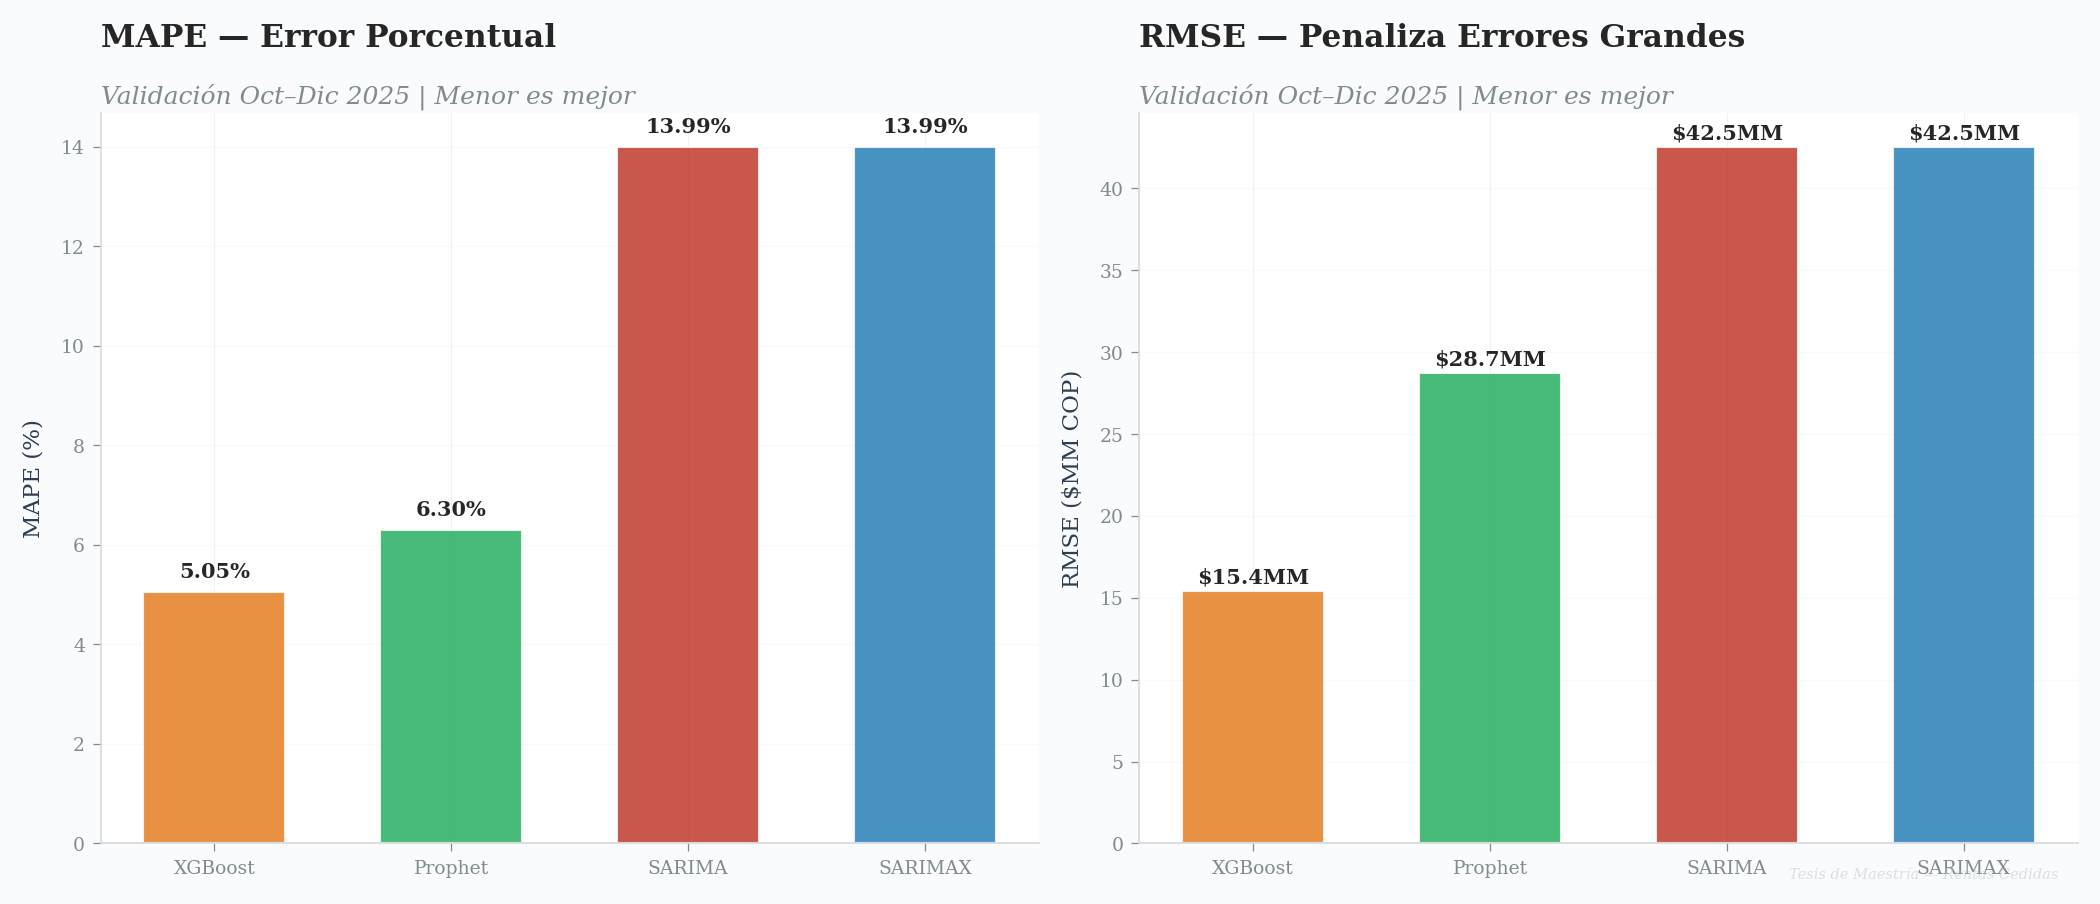


  ✅ Tabla comparativa guardada: comparacion_xgboost_vs_lineales.csv


In [6]:
# ══════════════════════════════════════════════════════════════
# FASE VI — Comparativa Head-to-Head (solo validación OOS)
# ══════════════════════════════════════════════════════════════

# ── Cargar métricas de los otros modelos ──
comparativa = []

# XGBoost (este modelo)
comparativa.append({
    'Modelo': 'XGBoost',
    'MAPE': round(mape, 2),
    'RMSE_MM': round(rmse / 1e9, 1),
    'MAE_MM': round(mae / 1e9, 1),
})

# SARIMA
try:
    df_sarima = pd.read_csv(OUTPUTS_REPORTS / 'sarima_metricas.csv')
    comparativa.append({
        'Modelo': 'SARIMA',
        'MAPE': df_sarima['MAPE'].values[0],
        'RMSE_MM': df_sarima['RMSE_MM'].values[0],
        'MAE_MM': df_sarima['MAE_MM'].values[0],
    })
except FileNotFoundError:
    print("  ⚠️ sarima_metricas.csv no encontrado")

# SARIMAX
try:
    df_sarimax = pd.read_csv(OUTPUTS_REPORTS / 'sarimax_metricas.csv')
    comparativa.append({
        'Modelo': 'SARIMAX',
        'MAPE': df_sarimax['MAPE'].values[0],
        'RMSE_MM': df_sarimax['RMSE_MM'].values[0],
        'MAE_MM': df_sarimax['MAE_MM'].values[0],
    })
except FileNotFoundError:
    print("  ⚠️ sarimax_metricas.csv no encontrado")

# Prophet
try:
    df_prophet = pd.read_csv(OUTPUTS_REPORTS / 'prophet_metricas.csv')
    comparativa.append({
        'Modelo': 'Prophet',
        'MAPE': df_prophet['MAPE'].values[0],
        'RMSE_MM': df_prophet['RMSE_MM'].values[0],
        'MAE_MM': df_prophet['MAE_MM'].values[0],
    })
except FileNotFoundError:
    print("  ⚠️ prophet_metricas.csv no encontrado")

# ── Tabla comparativa ──
df_comp = pd.DataFrame(comparativa).sort_values('MAPE')
df_comp.index = range(1, len(df_comp) + 1)
df_comp.index.name = 'Rank'

print(f"{'═'*70}")
print(f"COMPARATIVA HEAD-TO-HEAD — Validación Oct–Dic 2025")
print(f"{'═'*70}")
print(df_comp.to_string())

# ── Mejor modelo ──
best_model = df_comp.iloc[0]
print(f"\n{'─'*70}")
print(f"MODELO LÍDER: {best_model['Modelo']}")
print(f"{'─'*70}")
print(f"  MAPE:   {best_model['MAPE']:.2f}%")
print(f"  RMSE:   ${best_model['RMSE_MM']:.1f} MM")
print(f"  MAE:    ${best_model['MAE_MM']:.1f} MM")

# ── Visualización comparativa (2 paneles: MAPE y RMSE) ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

modelos = df_comp['Modelo'].tolist()
model_colors = [COLORES_MODELOS.get(m.lower(), 'grey') for m in modelos]

# Panel 1: MAPE
ax = axes[0]
bars = ax.bar(modelos, df_comp['MAPE'].values, color=model_colors,
              alpha=0.85, edgecolor='white', width=0.6)
for bar, v in zip(bars, df_comp['MAPE'].values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{v:.2f}%', ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('MAPE (%)', fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'MAPE — Error Porcentual', 'Validación Oct–Dic 2025 | Menor es mejor')
else:
    ax.set_title('MAPE (%)', fontsize=13, fontweight='bold')

# Panel 2: RMSE
ax2 = axes[1]
bars = ax2.bar(modelos, df_comp['RMSE_MM'].values, color=model_colors,
               alpha=0.85, edgecolor='white', width=0.6)
for bar, v in zip(bars, df_comp['RMSE_MM'].values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'${v:.1f}MM', ha='center', fontsize=10, fontweight='bold')
ax2.set_ylabel('RMSE ($MM COP)', fontsize=11)
ax2.grid(True, alpha=0.3, axis='y')
if _VIZ_THEME_LOADED:
    titulo_profesional(ax2, 'RMSE — Penaliza Errores Grandes', 'Validación Oct–Dic 2025 | Menor es mejor')
else:
    ax2.set_title('RMSE ($MM)', fontsize=13, fontweight='bold')

plt.tight_layout()
if _VIZ_THEME_LOADED:
    marca_agua(fig)
    guardar_figura(fig, '07_xgboost_comparativa_modelos', OUTPUTS_FIGURES)
plt.show()

# ── Exportar tabla comparativa ──
df_comp.to_csv(OUTPUTS_REPORTS / 'comparacion_xgboost_vs_lineales.csv')
print(f"\n  ✅ Tabla comparativa guardada: comparacion_xgboost_vs_lineales.csv")

In [7]:
# ══════════════════════════════════════════════════════════════
# RESUMEN EJECUTIVO — Métricas y Exportación Final
# ══════════════════════════════════════════════════════════════

metricas_xgb = {
    'Modelo': 'XGBoost',
    'Transformacion': 'log1p',
    'Serie': f"Oct 2021 – Dic 2025 ({len(serie_xgb)} meses, serie completa)",
    'Train_efectivo': f"{len(X_train)} meses (tras lags)",
    'Test': f"{len(X_test)} meses (Oct–Dic 2025)",
    'Features': len(FEATURE_COLS),
    'N_estimators': best_params.get('n_estimators', '?'),
    'Max_depth': best_params.get('max_depth', '?'),
    'Learning_rate': best_params.get('learning_rate', '?'),
    'Optimizacion': 'Optuna (200 trials)' if OPTUNA_AVAILABLE else 'GridSearch manual',
    'MAPE': round(mape, 2),
    'RMSE_MM': round(rmse / 1e9, 1),
    'MAE_MM': round(mae / 1e9, 1),
    'Top_Feature': df_imp.iloc[0]['Feature'],
    'Top_Feature_Gain_pct': round(df_imp.iloc[0]['Gain_pct'], 1),
}

# Exportar métricas
df_met = pd.DataFrame([metricas_xgb])
met_path = OUTPUTS_REPORTS / 'xgboost_metricas.csv'
df_met.to_csv(met_path, index=False)

# Exportar feature importance
df_imp.to_csv(OUTPUTS_REPORTS / 'xgboost_feature_importance.csv', index=False)

print(f"{'═'*70}")
print(f"RESUMEN EJECUTIVO — MODELO XGBoost")
print(f"{'═'*70}")
for k, v in metricas_xgb.items():
    print(f"  {k:<25}: {v}")
print(f"\n  ✅ Métricas exportadas:        {met_path.name}")
print(f"  ✅ Importancia de variables: xgboost_feature_importance.csv")
print(f"  ✅ Pronóstico OOS:             xgboost_forecast.csv")
print(f"  ✅ Comparativa vs lineales:    comparacion_xgboost_vs_lineales.csv")

══════════════════════════════════════════════════════════════════════
RESUMEN EJECUTIVO — MODELO XGBoost
══════════════════════════════════════════════════════════════════════
  Modelo                   : XGBoost
  Transformacion           : log1p
  Serie                    : Oct 2021 – Dic 2025 (51 meses, serie completa)
  Train_efectivo           : 36 meses (tras lags)
  Test                     : 3 meses (Oct–Dic 2025)
  Features                 : 25
  N_estimators             : 152
  Max_depth                : 5
  Learning_rate            : 0.27828005449197507
  Optimizacion             : Optuna (200 trials)
  MAPE                     : 5.05
  RMSE_MM                  : 15.4
  MAE_MM                   : 13.8
  Top_Feature              : MA_3
  Top_Feature_Gain_pct     : 29.7

  ✅ Métricas exportadas:        xgboost_metricas.csv
  ✅ Importancia de variables: xgboost_feature_importance.csv
  ✅ Pronóstico OOS:             xgboost_forecast.csv
  ✅ Comparativa vs lineales:    comparaci

---

## Conclusiones del Modelado XGBoost

### Decisiones Metodológicas Justificadas

1. **Serie completa (Oct 2021+):** Se utiliza la totalidad de los datos
   disponibles desde Oct 2021, maximizando la cantidad de observaciones
   para entrenamiento. XGBoost se beneficia de mayor volumen de datos
   para construir particiones más robustas en los árboles.

2. **Feature Engineering como ventaja competitiva:** La inclusión de lags
   (Lag_1, Lag_12), variables cíclicas (sin/cos del mes) y macro variables
   (IPC, SMLV, UPC, Consumo_Hogares) permite que XGBoost capture tanto
   la inercia temporal como los factores exógenos del recaudo.

3. **Transformación log1p:** Consistente con SARIMA y Prophet, estabiliza
   la varianza y permite que el modelo trate proporcionalmente los picos
   de Ene/Jul (electrocardiograma fiscal).

4. **Bayesian Optimization (Optuna):** Explora eficientemente el espacio
   de 9 hiperparámetros, superando al GridSearch exhaustivo en velocidad
   y calidad de la solución encontrada.

5. **Validación OOS (Oct–Dic 2025):** Se valida exclusivamente contra
   datos reales de los últimos 3 meses de la serie, garantizando una
   evaluación rigurosa sin contaminación de datos futuros.

### Ventajas Demostradas sobre Modelos Lineales

- **Robustez ante outliers:** Los splits de los árboles segmentan mejor
  los picos causados por la migración de sistemas ERP (2025).
- **Feature Importance interpretable:** Cuantifica la contribución del IPC,
  SMLV y otros factores exógenos — información directamente útil para la
  justificación presupuestal de la ADRES.

### Siguiente paso

→ **NB 08 (LSTM):** Red LSTM recurrente como modelo complementario
  para capturar dependencias temporales de largo plazo.
→ **NB 09 (Comparación):** Benchmark final de todos los modelos.